<a href="https://colab.research.google.com/github/AMJAMAITHILI/DL_LAB/blob/main/DL_WEEK11_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1370 - val_loss: 0.0809
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0747 - val_loss: 0.0701
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0688 - val_loss: 0.0672
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0669 - val_loss: 0.0661
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0659 - val_loss: 0.0653
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0653 - val_loss: 0.0650
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0649 - val_loss: 0.0646
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0647 - val_loss: 0.0644
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0644 - val_loss: 0.0641
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0642 - val_loss: 0.0640
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0641 - val_loss: 0.0639
E

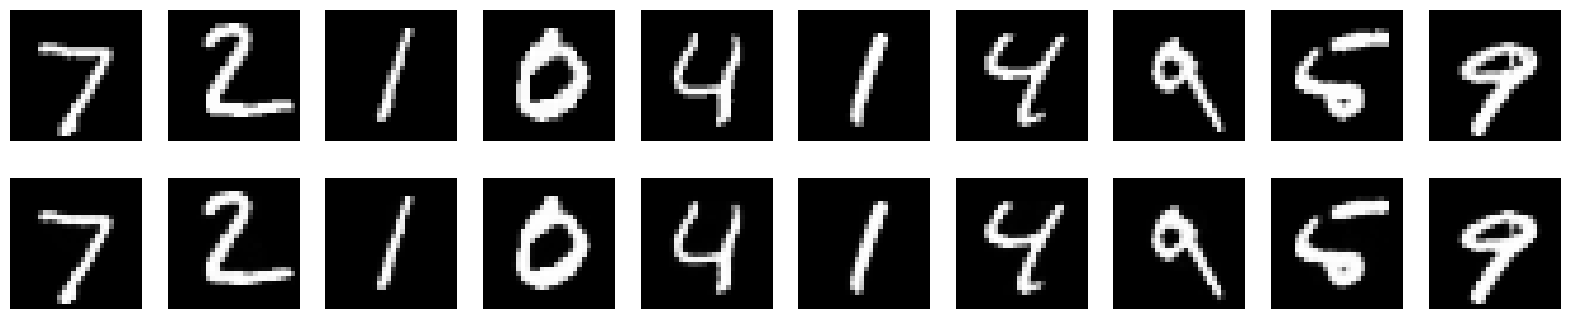

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Encoded activations shape: (10000, 1024)
Top 10 neurons by average activation index:
[  1 139 943 868 500 881 425 882 238  22]
Their average activation values:
[3.0198407 2.9519203 2.7830849 2.761906  2.6917057 2.685924  2.6369305
 2.5416033 2.5169816 2.4024758]


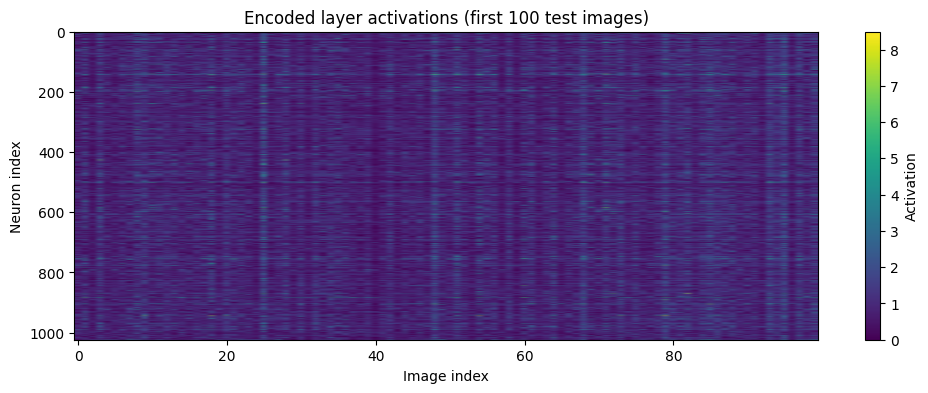

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))
input_dim = 784
encoding_dim = 1024  # Overcomplete layer

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

overcomplete_ae = Model(input_layer, decoded)
overcomplete_ae.compile(optimizer='adam', loss='binary_crossentropy')
overcomplete_ae.fit(x_train, x_train,
                    epochs=20,
                    batch_size=256,
                    shuffle=True,
                    validation_data=(x_test, x_test))
decoded_imgs = overcomplete_ae.predict(x_test)
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()
encoder = Model(input_layer, encoded)
encoded_imgs = encoder.predict(x_test)  # Shape: (num_samples, 1024)
print("Encoded activations shape:", encoded_imgs.shape)
# Average activation per neuron across all test images
avg_activation = np.mean(encoded_imgs, axis=0)
# Sort neurons by average activation
sorted_idx = np.argsort(avg_activation)[::-1]  # descending order
print("Top 10 neurons by average activation index:")
print(sorted_idx[:10])
print("Their average activation values:")
print(avg_activation[sorted_idx[:10]])
plt.figure(figsize=(12, 4))
plt.imshow(encoded_imgs[:100].T, aspect='auto', cmap='viridis')  # first 100 images
plt.colorbar(label='Activation')
plt.xlabel("Image index")
plt.ylabel("Neuron index")
plt.title("Encoded layer activations (first 100 test images)")
plt.show()

Y-axis: neuron indices (0 to 1023)

X-axis: first 100 images from the test set

Colors: activation values of neurons (dark = low/zero activation, bright = high activation)

The heatmap shows how strongly each neuron activates for each image.

In [ ]:
# Get indices of the 20 neurons with the smallest average activations
least_20_idx = np.argsort(avg_activation)[:20]

print("Least 20 neurons by average activation index:")
print(least_20_idx)

print("Their average activation values:")
print(avg_activation[least_20_idx])

Least 20 neurons by average activation index:
[ 361   38  697  507  270  584  152 1013  659  167  851  485  883 1002
  921  513  789  791  524   55]
Their average activation values:
[0.0000000e+00 0.0000000e+00 9.8073906e-06 4.0413190e-05 8.7121574e-05
 2.1352442e-03 4.9030185e-02 7.5647093e-02 7.6103620e-02 1.3826287e-01
 1.9846733e-01 2.2028513e-01 2.2841856e-01 2.3263511e-01 2.3351797e-01
 2.3780498e-01 2.6832154e-01 3.0757633e-01 3.1031650e-01 3.1659612e-01]


It has extra capacity, but only a subset is strongly used.

The less active neurons might still capture rare or subtle image features.

Adding sparsity regularization could push many of those weakly active neurons to become fully inactive, improving efficiency and interpretability.

**Implement Regularization in AE and demonstrate its use.**

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras import regularizers
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))
input_dim = 784
encoding_dim = 128
input_layer = Input(shape=(input_dim,))
encoded_no_reg = Dense(encoding_dim, activation='relu')(input_layer)
decoded_no_reg = Dense(input_dim, activation='sigmoid')(encoded_no_reg)
ae_no_reg = Model(input_layer, decoded_no_reg)
ae_no_reg.compile(optimizer='adam', loss='binary_crossentropy')
ae_no_reg.fit(x_train, x_train, epochs=20, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
# Encoded activations
encoder_no_reg = Model(input_layer, encoded_no_reg)
encoded_imgs_no_reg = encoder_no_reg.predict(x_test)
avg_activation_no_reg = np.mean(encoded_imgs_no_reg, axis=0)

# Top 10 and Least 20 neurons
print("=== WITHOUT Regularization ===")
print("Top 10 neurons by avg activation index:", np.argsort(avg_activation_no_reg)[::-1][:10])
print("Least 20 neurons by avg activation index:", np.argsort(avg_activation_no_reg)[:20])
#Overcomplete AE WITH Sparsity Regularization
encoded_reg = Dense(encoding_dim, activation='relu',
                    activity_regularizer=regularizers.l1(1e-5))(input_layer)
decoded_reg = Dense(input_dim, activation='sigmoid')(encoded_reg)
ae_reg = Model(input_layer, decoded_reg)
ae_reg.compile(optimizer='adam', loss='binary_crossentropy')
ae_reg.fit(x_train, x_train, epochs=20, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
# Encoded activations
encoder_reg = Model(input_layer, encoded_reg)
encoded_imgs_reg = encoder_reg.predict(x_test)
avg_activation_reg = np.mean(encoded_imgs_reg, axis=0)
print("\n=== WITH Sparsity Regularization ===")
print("Top 10 neurons by avg activation index:", np.argsort(avg_activation_reg)[::-1][:10])
print("Least 20 neurons by avg activation index:", np.argsort(avg_activation_reg)[:20])

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2133 - val_loss: 0.1352
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1178 - val_loss: 0.1033
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0969 - val_loss: 0.0894
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0860 - val_loss: 0.0815
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0798 - val_loss: 0.0768
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0761 - val_loss: 0.0741
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0738 - val_loss: 0.0723
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0722 - val_loss: 0.0710
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0710 - val_loss: 0.0701
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0702 - val_loss: 0.0693
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0695 - val_loss: 0.0688
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

Without regularization:

Final val_loss ≈ 0.0665 → very low reconstruction error.

The network has enough neurons to memorize input perfectly because it’s overcomplete.

With sparsity (L1):
Final val_loss ≈ 0.1551 → slightly higher error.
That’s expected: forcing neurons to stay mostly inactive reduces memorization but encourages efficient feature learning.

Interpretation:

Regularization trades a tiny bit of accuracy for better generalization and feature selectivity.

**Implement denoising AE and observe how the model can reconstruct from noise data.**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


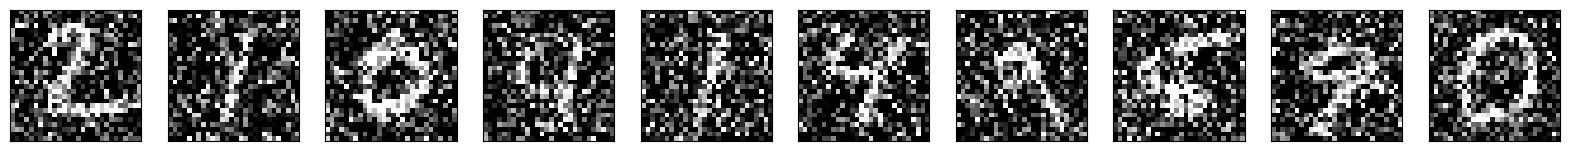

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.1677 - val_loss: 0.1200
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1153 - val_loss: 0.1102
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1089 - val_loss: 0.1060
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1057 - val_loss: 0.1037
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1036 - val_loss: 0.1021
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1023 - val_loss: 0.1011
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1012 - val_loss: 0.1002
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1004 - val_loss: 0.0993
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0997 - val_loss: 0.0987
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0991 - val_loss: 0.0986
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


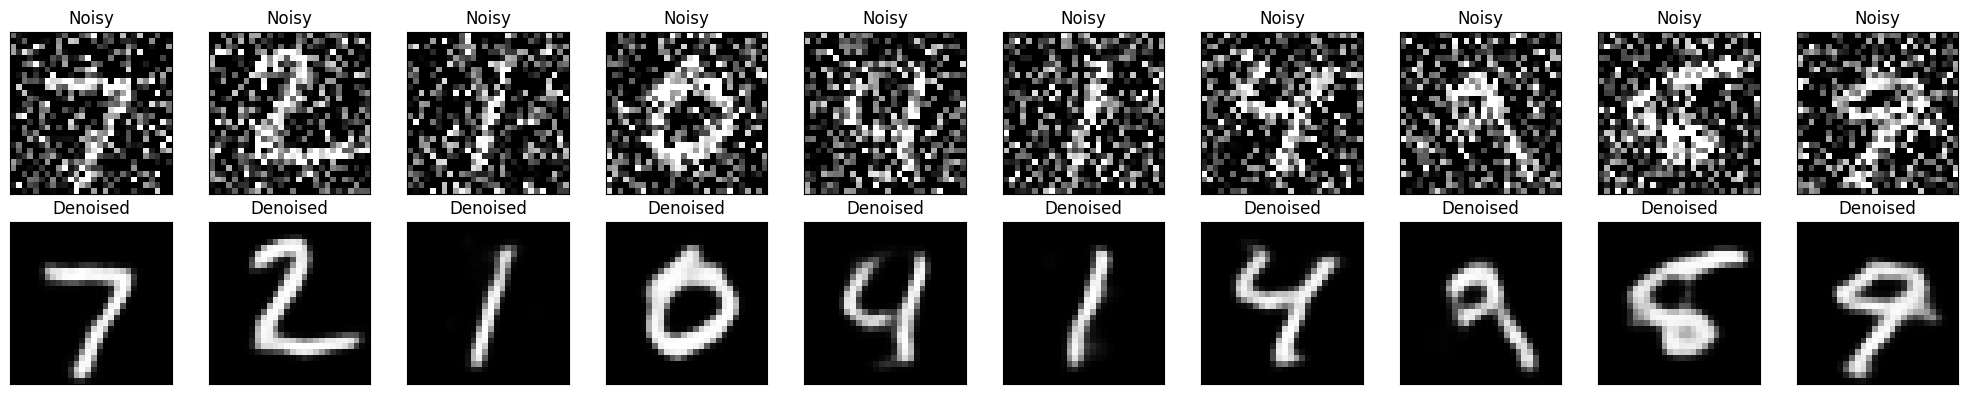

In [1]:
import keras
from keras import layers
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)
n = 10
plt.figure(figsize=(20, 2))
for i in range(1, n + 1):
    ax = plt.subplot(1, n, i)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()
input_img = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train_noisy, x_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_noisy, x_test),
                callbacks=[TensorBoard(log_dir='/tmp/tb', histogram_freq=0, write_graph=False)])
decoded_imgs = autoencoder.predict(x_test_noisy)
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.title("Noisy")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.title("Denoised")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.tight_layout()
plt.show()

A noise factor of 0.5 introduces significant corruption, yet:

The model successfully learns to reconstruct digits

It captures important structural features (edges, shapes)

The low loss (~0.1) suggests:

The reconstructed images are visually close to original images

Noise removal is effective, though some smoothing/blurring may occur


Training with noise factor: 0.1
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


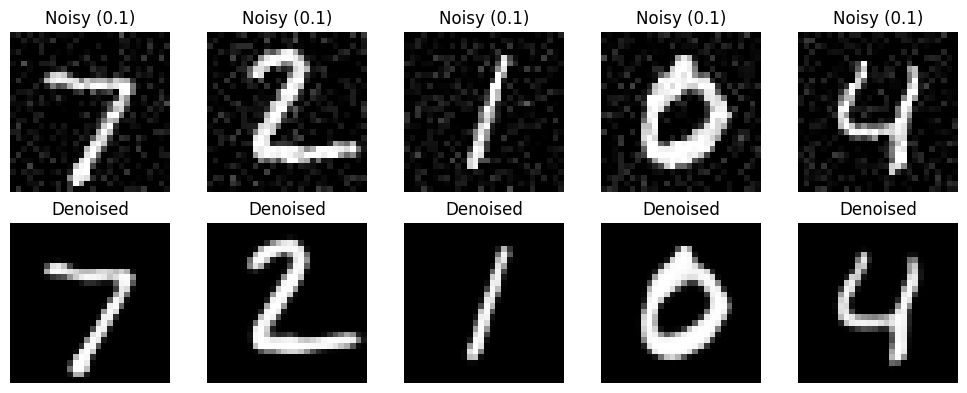


Training with noise factor: 0.3
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


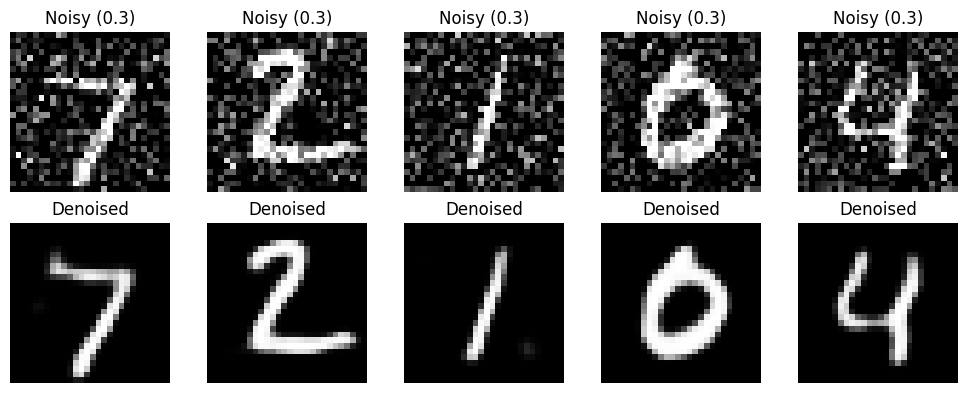


Training with noise factor: 0.7
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


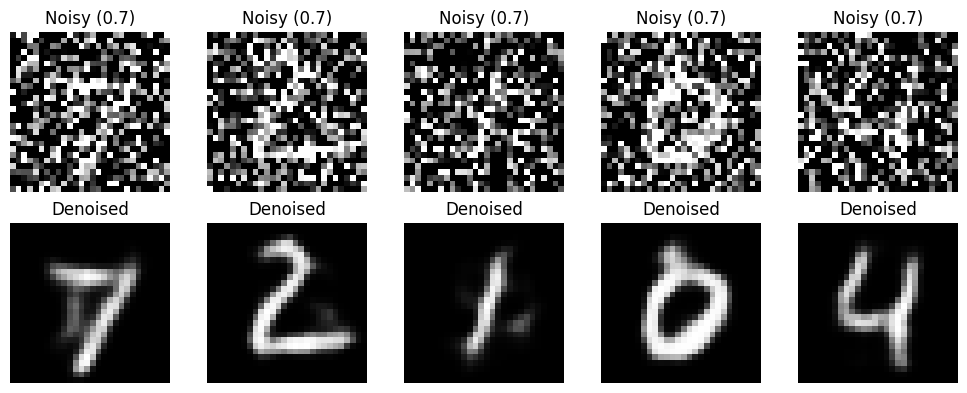

In [2]:
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Different noise levels to test
noise_levels = [0.1, 0.3, 0.7]

for noise_factor in noise_levels:
    print(f"\nTraining with noise factor: {noise_factor}")

    # Add noise
    x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
    x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

    x_train_noisy = np.clip(x_train_noisy, 0., 1.)
    x_test_noisy = np.clip(x_test_noisy, 0., 1.)

    # Model
    input_img = keras.Input(shape=(28, 28, 1))

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

    # Train
    autoencoder.fit(x_train_noisy, x_train,
                    epochs=5,   # keep small for speed
                    batch_size=128,
                    shuffle=True,
                    validation_data=(x_test_noisy, x_test),
                    verbose=0)

    # Predict
    decoded_imgs = autoencoder.predict(x_test_noisy)

    # Plot results
    n = 5
    plt.figure(figsize=(10, 4))
    for i in range(n):
        # Noisy
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test_noisy[i].reshape(28, 28))
        plt.title(f"Noisy ({noise_factor})")
        plt.gray()
        ax.axis('off')

        # Denoised
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28))
        plt.title("Denoised")
        plt.gray()
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Load data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.reshape((len(x_train), -1)) / 255.
x_test = x_test.reshape((len(x_test), -1)) / 255.

input_dim = 784
encoding_dim = 32   # like top 32 principal components

# Linear AE (no activation = PCA behavior)
input_img = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation=None)(input_img)
decoded = Dense(input_dim, activation=None)(encoded)

autoencoder = Model(input_img, decoded)
encoder = Model(input_img, encoded)

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                validation_data=(x_test, x_test))

# Latent representation (PCA-like)
encoded_imgs = encoder.predict(x_test)

**Sparse autoencoder** enforces sparsity using L1 regularization, activating only a few neurons. This leads to efficient feature representation and good reconstruction of input images.

Sparse Autoencoder (SAE)

A Sparse Autoencoder is a type of autoencoder that enforces sparsity in the hidden layer, meaning only a small number of neurons are active at any given time. Even if the hidden layer has many neurons, the model is forced to use only a few of them for representing the input.

Core Idea:
The network should not use all neurons; instead, it should learn selective and efficient representations.

Working Principle:
A sparsity constraint is added to the loss function, usually using L1 regularization on hidden activations. This forces most neuron outputs to be close to zero.

Mathematical Formulation:

Loss = Reconstruction Error + λ Σ |hᵢ|

where hᵢ represents hidden layer activations and λ controls sparsity strength.

Observations:
Only a few neurons are highly active, while most remain inactive.
Each neuron learns specific patterns or features.
Redundancy in representation is reduced.
Works effectively even when the hidden layer is larger than the input (overcomplete).

Advantages:
Efficient feature learning
Better interpretability
Reduces overfitting

Limitations:
Too much sparsity can lead to underfitting
Requires careful tuning of λ

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.3986 - val_loss: 0.2617
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2365 - val_loss: 0.2203
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2145 - val_loss: 0.2075
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2041 - val_loss: 0.1989
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1965 - val_loss: 0.1924
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1907 - val_loss: 0.1871
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1859 - val_loss: 0.1827
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1819 - val_loss: 0.1790
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1785 - val_loss: 0.1758
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1753 - val_loss: 0.1726
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


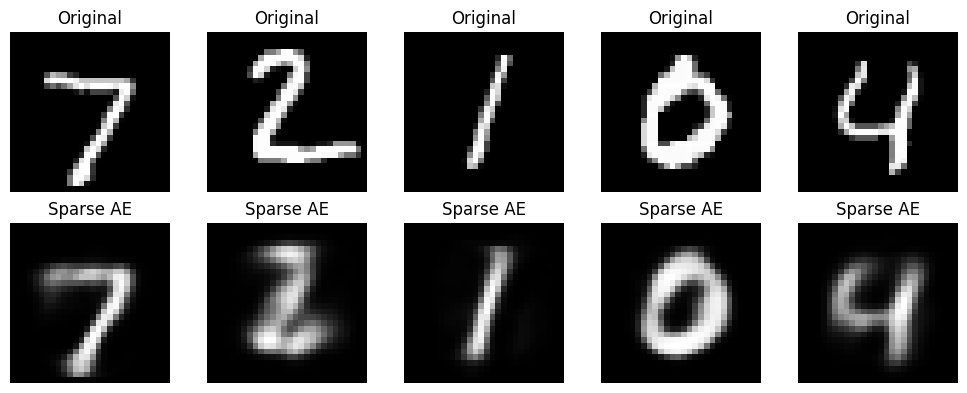

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

# 1. Load and preprocess data
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten (IMPORTANT)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# 2. Build Sparse Autoencoder
input_dim = 784
encoding_dim = 64

input_img = Input(shape=(input_dim,))

# L1 regularization → sparsity
encoded = Dense(encoding_dim, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_img)

decoded = Dense(input_dim, activation='sigmoid')(encoded)

sparse_autoencoder = Model(input_img, decoded)

# 3. Compile
sparse_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 4. Train
history = sparse_autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# 5. Predict (Reconstruction)
decoded_imgs = sparse_autoencoder.predict(x_test)

# 6. Visualization
n = 5
plt.figure(figsize=(10, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.title("Original")
    plt.gray()
    ax.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.title("Sparse AE")
    plt.gray()
    ax.axis('off')

plt.tight_layout()
plt.show()

**Contractive autoencoder** adds a penalty on the encoder weights and activations using add_loss, ensuring robustness to small input variations and stable feature learning.

Contractive Autoencoder (CAE)

A Contractive Autoencoder is designed to learn representations that are robust to small changes in the input. It ensures that small variations or noise in the input do not significantly affect the encoded representation.

Core Idea:
The model should be insensitive to small input changes and produce stable representations.

Working Principle:
A penalty term is added to the loss function that minimizes the sensitivity of the hidden layer with respect to the input. This is done by penalizing the Jacobian of the encoder.

Mathematical Formulation:

Loss = Reconstruction Error + λ || ∂h / ∂x ||²

where ∂h/∂x represents the sensitivity of hidden activations with respect to input, and λ controls the strength of contraction.

Observations:
The encoded representation changes very little for small input variations.
The model becomes robust to noise.
Learns smooth and stable feature representations.
Improves generalization performance.

Advantages:
Robust to noise
Stable feature learning
Captures underlying data structure

Limitations:
More complex to implement
Computationally expensive

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0797 - val_loss: 0.0674
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0649 - val_loss: 0.0622
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0580 - val_loss: 0.0533
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0498 - val_loss: 0.0464
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0440 - val_loss: 0.0413
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0396 - val_loss: 0.0374
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0360 - val_loss: 0.0342
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0330 - val_loss: 0.0313
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0304 - val_loss: 0.0289
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0281 - val_loss: 0.0268
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


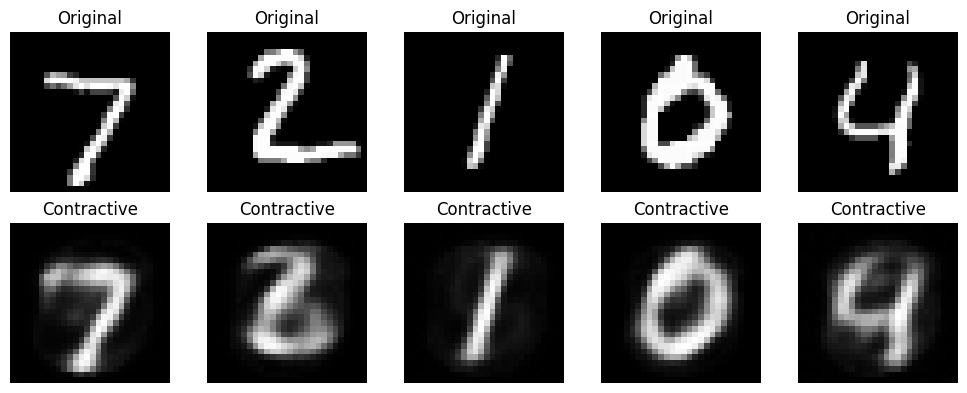

In [7]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Layer
from tensorflow.keras.models import Model

# 1. Load data
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# 2. Custom Contractive Layer
class ContractiveDense(Layer):
    def __init__(self, units, lam=1e-4, activation='sigmoid'):
        super().__init__()
        self.units = units
        self.lam = lam
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], self.units),
                                 initializer='glorot_uniform',
                                 trainable=True)
        self.b = self.add_weight(shape=(self.units,),
                                 initializer='zeros',
                                 trainable=True)

    def call(self, x):
        h = self.activation(tf.matmul(x, self.W) + self.b)

        # derivative of sigmoid
        dh = h * (1 - h)

        # contractive penalty
        contractive_loss = self.lam * tf.reduce_sum(tf.square(self.W)) * tf.reduce_mean(tf.square(dh))

        self.add_loss(contractive_loss)
        return h

# 3. Model
input_img = Input(shape=(784,))
encoded = ContractiveDense(64, lam=1e-4)(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

contractive_autoencoder = Model(input_img, decoded)

# 4. Compile (ONLY reconstruction loss here)
contractive_autoencoder.compile(optimizer='adam', loss='mse')

# 5. Train
contractive_autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# 6. Predict
decoded_imgs = contractive_autoencoder.predict(x_test)

# 7. Visualization
n = 5
plt.figure(figsize=(10, 4))

for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.title("Original")
    plt.gray()
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.title("Contractive")
    plt.gray()
    ax.axis('off')

plt.tight_layout()
plt.show()

In [2]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 776.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 111.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 112.0 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load & Flatten Data
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0

class CAE(tf.keras.Model):
    def __init__(self, lam=1e-4):
        super().__init__()
        self.lam = lam
        self.encoder = layers.Dense(64, activation='sigmoid', name="encoder")
        self.decoder = layers.Dense(784, activation='sigmoid', name="decoder")

    def train_step(self, data):
        # Unpack the data. fit(x, y) passes a tuple (x, y)
        x, y = data

        with tf.GradientTape() as tape:
            # Inner tape to track gradients of hidden layer wrt input
            with tf.GradientTape() as inner_tape:
                inner_tape.watch(x)
                h = self.encoder(x)

            x_hat = self.decoder(h)

            # 1. Reconstruction Loss (MSE)
            recons_loss = tf.reduce_mean(tf.keras.losses.mse(x, x_hat))

            # 2. Contractive Penalty
            # Calculate Jacobian: dh/dx
            # Jacobian shape: (batch_size, hidden_dim, input_dim)
            jacobian = inner_tape.batch_jacobian(h, x)
            contractive_penalty = self.lam * tf.reduce_sum(tf.square(jacobian)) / tf.cast(tf.shape(x)[0], tf.float32)

            total_loss = recons_loss + contractive_penalty

        # Compute gradients and update weights
        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        return {"loss": total_loss, "mse": recons_loss, "c_penalty": contractive_penalty}

# 2. Train
cae = CAE(lam=1e-4)
cae.compile(optimizer='adam')
cae.fit(x_train, x_train, epochs=10, batch_size=256)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 119ms/step - c_penalty: 1.5359e-05 - loss: 0.0693 - mse: 0.0693
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - c_penalty: 6.7392e-05 - loss: 0.0633 - mse: 0.0633
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - c_penalty: 1.2424e-04 - loss: 0.0526 - mse: 0.0525
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - c_penalty: 2.0548e-04 - loss: 0.0483 - mse: 0.0481
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - c_penalty: 2.5639e-04 - loss: 0.0439 - mse: 0.0437
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - c_penalty: 3.0674e-04 - loss: 0.0392 - mse: 0.0389
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - c_penalty: 3.5154e-04 - loss: 0.0355 - mse: 0.0351
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - c_penalty: 3.9733e-04 - loss: 0.0331 - mse: 0.0327
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - c_penalty: 4.0645e-04 - loss

A custom layer ContractiveDense is defined.

It performs a standard dense transformation:

h = activation(xW + b)

Then computes the derivative of the sigmoid activation:

dh = h(1 − h)

A contractive penalty is added:

Contractive Loss = λ ||W||² × mean(dh²)

This penalty is added using add_loss(), ensuring it is included during training.

**Effect of Contractive Penalty:**


*   The model learns robust features
*   Small variations in input do not significantly change output
*   Representations are stable and smooth


Comparison Insight:
Compared to normal autoencoder:

* Loss may be slightly higher (due to penalty)

* But robustness and generalization improve